# Fig: example MAP search

This notebook:
- plots a figure for an MAP search without misses or false alarms
- use the run identified in `20251028_fig_MAP_simple_search_find_run.ipynb`

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib

from infotaxis import utils_plot_hex, hex_ops

In [2]:
path_data = Path("../simulations/20251026_revised_run") # fixed target location

path_fig = Path("../figs")

In [3]:
search_type = "MAP"
cr = 5
br = 1
pm = 0.005

# folder = f"20251027_{search_type}_pmaxRepeat_canvasRadius{cr}_beamRadius{br}_pm{pm:.0e}_pfa{pm:.0e}"
folder = f"20251026_{search_type}_pmaxRepeat_canvasRadius{cr}_beamRadius{br}_pm{pm:.0e}_pfa{pm:.0e}"

In [4]:
run_number = 376
nc_fname = f"{search_type}_{run_number:04d}.nc"
ds = xr.open_dataset(path_data / folder / nc_fname, engine="netcdf4")

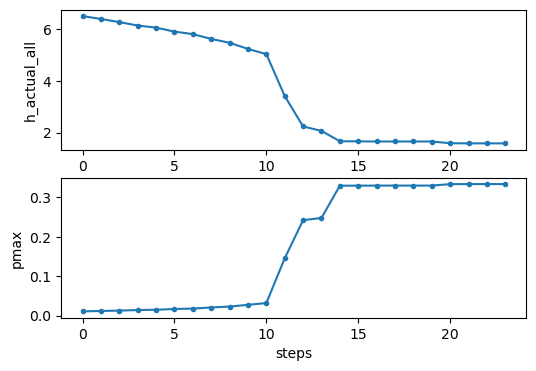

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(6,4))
ds["h_actual_all"].plot(marker=".", ax=ax[0])
(ds["d_all"].max(dim="canvas")).plot(marker=".", ax=ax[1])
ax[1].set_ylabel("pmax")
plt.show()

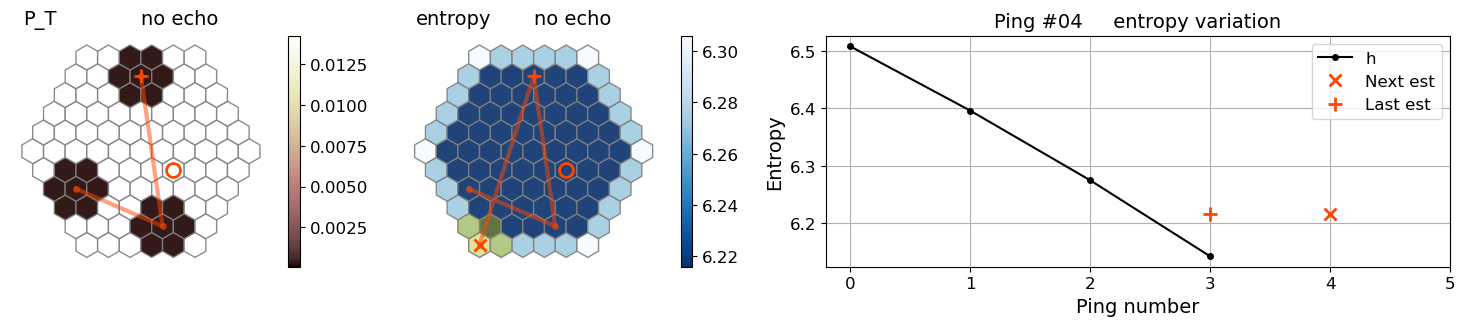

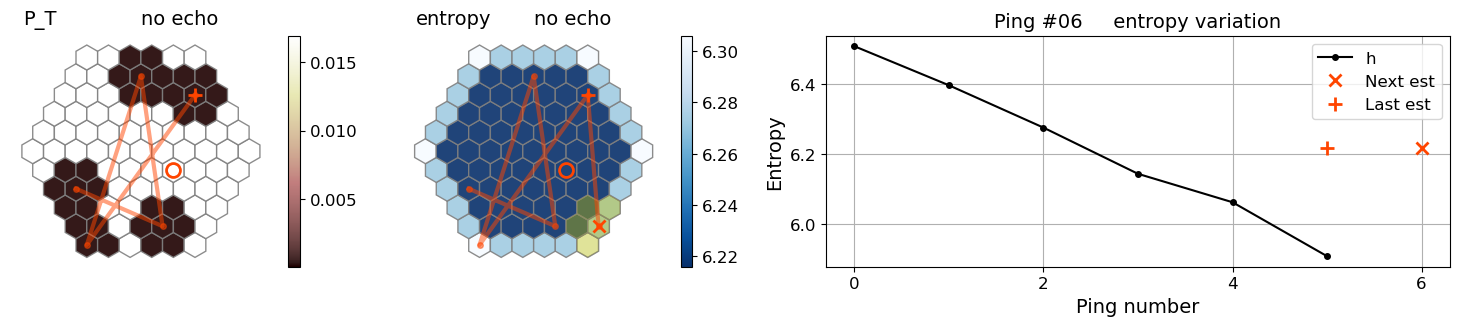

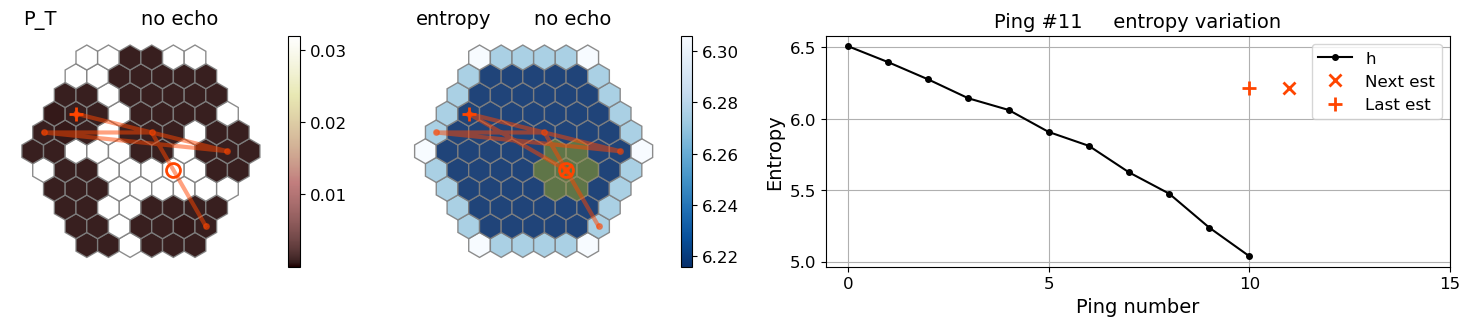

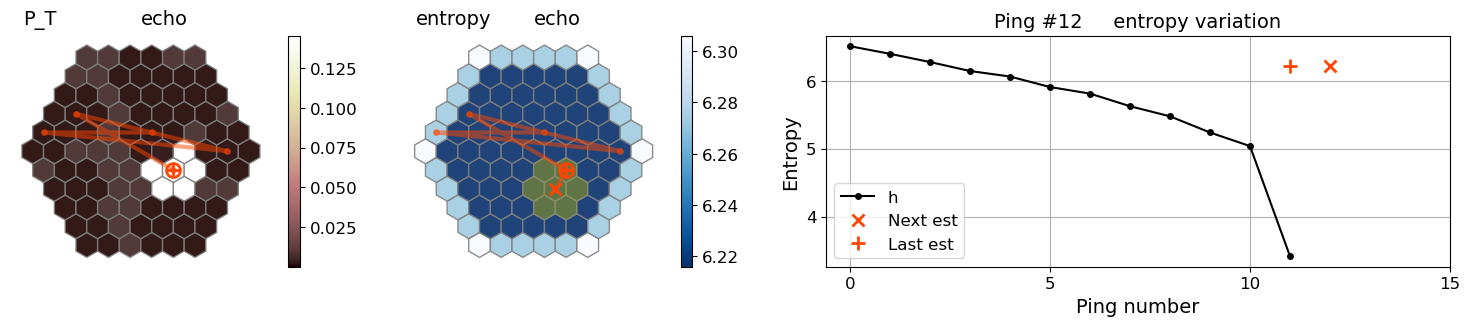

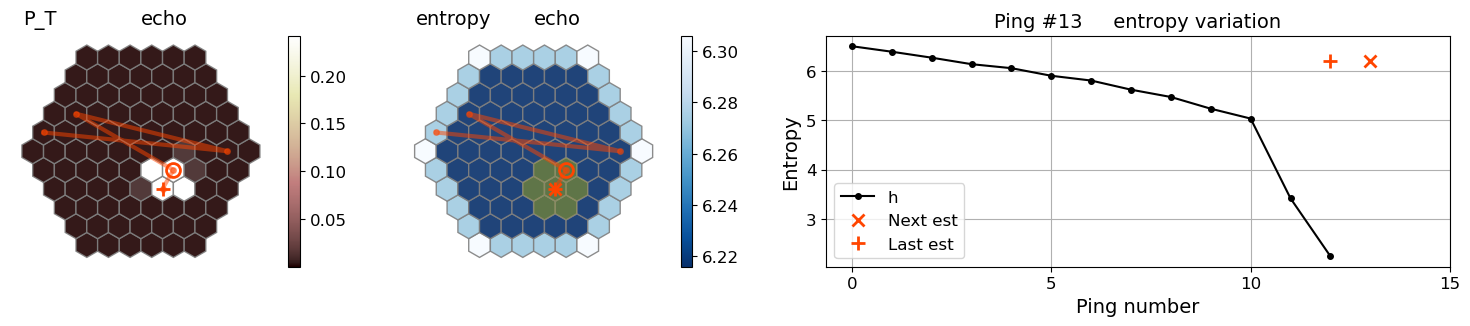

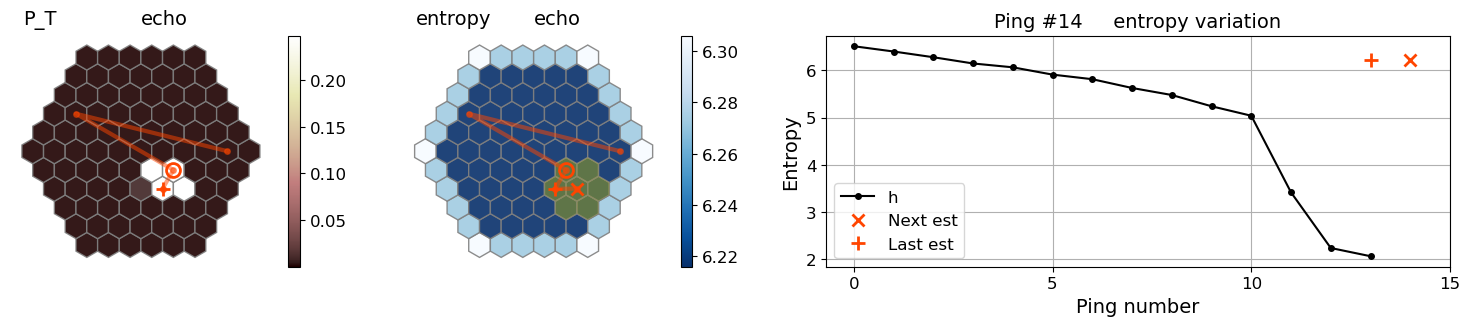

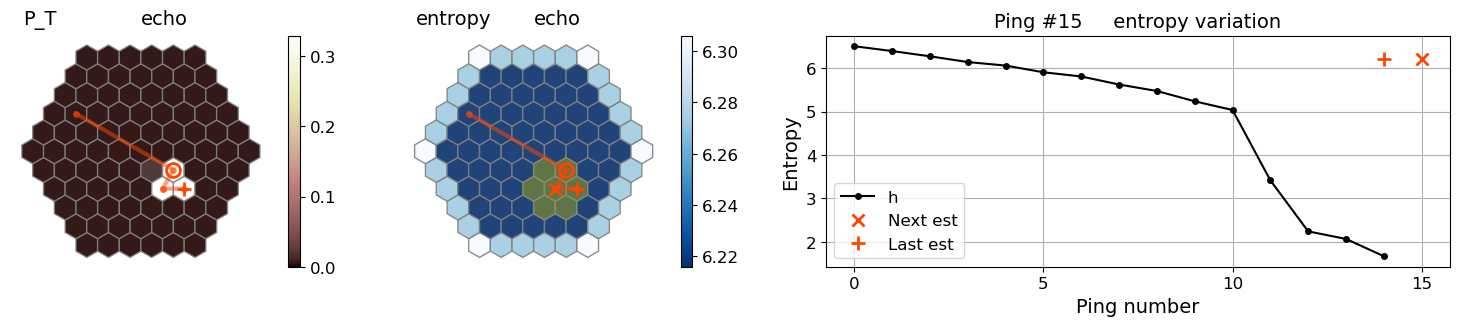

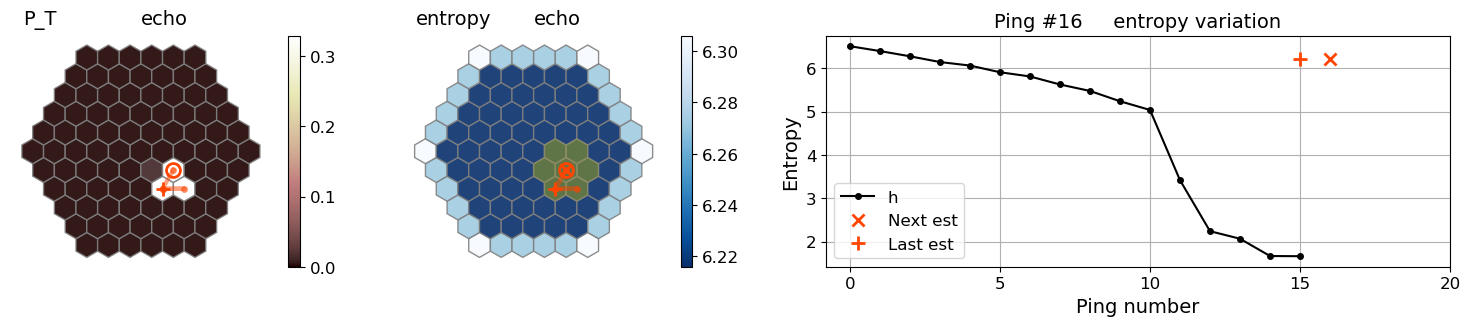

In [6]:
pings_to_plot = np.array([4, 6, 11, 12 ,13, 14, 15, 16])
idx_to_plot = pings_to_plot-1
for idx in idx_to_plot:
    utils_plot_hex.plot_step_from_nc(ds, idx)

In [7]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_loc_standalone(ax, axis_ij, sym='o', color='m', size=10):
    ax.plot(axis_ij[0], axis_ij[1],
            markersize=size,
            marker=sym,
            markerfacecolor="None",
            markeredgecolor=color,
            markeredgewidth=1.5)

In [8]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_dk_map_standalone(ax, canvas_cube, canvas_vmap,
    beam_cube, env_attrs, plot_attrs, cmap="Blues_r",
    remove_cbar=False
):
    im, cbar = hex_ops.plot_hexgrids(ax,
                                     cube_array=canvas_cube,
                                     cube_color=canvas_vmap,
                                     cmap=cmap)
    ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])
    ax.axis('equal')

    # Beam and beam trace
    beam_plotxy = np.array([hex_ops.get_cube_plot_xy(x).squeeze()
                            for x in beam_cube])
    beam_trace = beam_plotxy[-6:, :]    # plot last 5 beam axis loc and the next
    beam_next = beam_plotxy[-1, :]   # next beam axis loc

    ax.plot(beam_trace[:, 0], beam_trace[:, 1], marker='.',
            color=plot_attrs['symbol_color'], alpha=0.5, linewidth=2, markersize=4)
    if beam_plotxy.shape[0] > 1:  # if there was a last beam
        plot_loc_standalone(ax=ax, axis_ij=beam_plotxy[-2, :],  # plot last beam axis
                 sym='+', color=plot_attrs['symbol_color'], size=8)
    if beam_next is not None:
        plot_loc_standalone(ax=ax, axis_ij=beam_next,  # plot last beam axis
                 sym='x', color=plot_attrs['symbol_color'], size=6)

    # Target and peg locs
    if 'target_loc' in env_attrs:
        plot_loc_standalone(ax, hex_ops.get_cube_plot_xy(env_attrs['target_loc']),
                 sym='o', color=plot_attrs['symbol_color'], size=8)  # target location

    # cbar.ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])
    if remove_cbar:
        cbar.remove()
    else:
        pos = cbar.ax.get_position()
        cbar.ax.set_position([pos.x0 - 0.05, pos.y0, pos.width, pos.height])
        cbar.ax.set_yticks([])

In [9]:
plot_attrs = utils_plot_hex.PLOT_ATTRS
plot_attrs

{'ticklabel_fontsize': 12,
 'title_fontsize': 14,
 'axislabel_fontsize': 14,
 'legend_fontsize': 12,
 'symbol_color': 'orangered'}

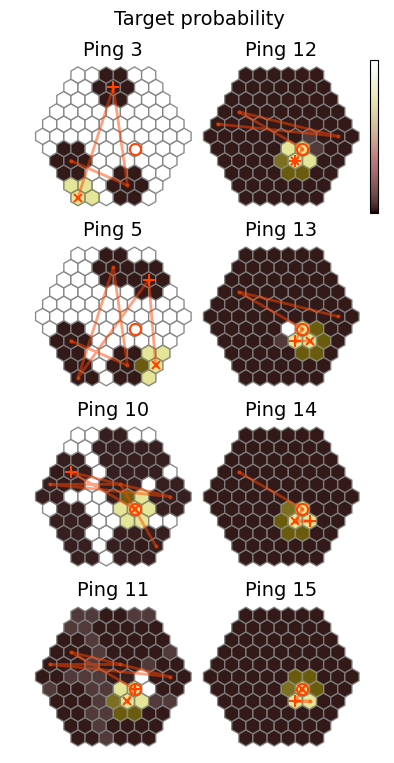

In [10]:
# Construct env_attrs for plotting
env_attrs = dict(target_loc=ds.attrs['target_loc'])

fig, ax_all = plt.subplots(4, 2, figsize=(5.5, 9))
fig.subplots_adjust(hspace=0.18, wspace=-0.35)

for seq, ping_num in enumerate(idx_to_plot):

    # Whether remove colorbar
    remove_cbar = False if seq==4 else True

    # Get beam radius
    beam_r = ds["radius_all"].isel(steps=ping_num).values

    # Target probability map
    if seq<4:
        ax = ax_all[seq, 0]
    else:
        ax = ax_all[seq-4, 1]
    plot_dk_map_standalone(
        ax,
        canvas_cube=ds['canvas_cube'].values,
        canvas_vmap=ds['d_all'].isel(steps=ping_num).values,
        beam_cube=ds['beam_cube_all'].isel(steps=slice(0, ping_num + 1)).values,
        env_attrs=env_attrs,
        plot_attrs=plot_attrs,
        cmap="pink",
        remove_cbar=remove_cbar
    )
    ax.set_title(f'Ping {ping_num}', fontsize=14, pad=0)
    # ttype = ax.text(x=0.25, y=1.0, s=f'Ping #{ping_num}',
    #             transform=ax.transAxes,
    #             fontsize=12)
    ax.patch.set_visible(False)
    ax.axis('off')

    # Next beam coverage
    canvas_axial = hex_ops.cube_to_axial(ds['canvas_cube'])  # the entire canvas in axial coordinate
    last_beam_cover_cube = utils_plot_hex.beam_shape_hex(cube_ctr=ds['beam_cube_all'].isel(steps=ping_num).values,
                                            canvas_axial=canvas_axial,
                                            beam_radius=beam_r)
    hex_ops.plot_hexgrids(ax, cube_array=last_beam_cover_cube,
                            cube_color='y', gridalpha=0.4)

    ax.patch.set_visible(False)
    ax.axis('off')


fig.text(0.47, 0.925, 'Target probability', 
         ha='center', va='center', fontsize=14,
         transform=fig.transFigure)

plt.show()


fig.savefig(path_fig / "fig_8A_MAP_search_A.png", dpi=300, bbox_inches="tight")

In [11]:
p_max = ds["d_all"].max(dim="canvas").values
p_max

array([0.01098901, 0.01189978, 0.01297516, 0.01426421, 0.01512273,
       0.01690308, 0.01812385, 0.02074212, 0.02312876, 0.02756994,
       0.03196266, 0.14532847, 0.2419198 , 0.24762208, 0.32923484,
       0.32937277, 0.32951769, 0.32952221, 0.32952237, 0.32952738,
       0.33319997, 0.33332868, 0.33332871, 0.33332871])

In [12]:
pmax_diff_threshold=1e-5
criteria = {
    "pmax_repeat_N": 3,
    "max_ping_num": 500,
    "pmax_diff_threshold": pmax_diff_threshold,
}    
for p in range(len(p_max)):
    if p - criteria["pmax_repeat_N"] < 0:
        continue
    p_max_diff = np.diff(p_max[p-criteria["pmax_repeat_N"]+1:p+1])
    print(p_max_diff)
    if len(p_max_diff) > 1 and np.all(abs(p_max_diff) < criteria["pmax_diff_threshold"]):
        p_converged = p
        break

[0.00107538 0.00128905]
[0.00128905 0.00085852]
[0.00085852 0.00178035]
[0.00178035 0.00122077]
[0.00122077 0.00261827]
[0.00261827 0.00238664]
[0.00238664 0.00444118]
[0.00444118 0.00439271]
[0.00439271 0.11336581]
[0.11336581 0.09659133]
[0.09659133 0.00570228]
[0.00570228 0.08161276]
[0.08161276 0.00013793]
[0.00013793 0.00014492]
[1.44922651e-04 4.52106218e-06]
[4.52106218e-06 1.56645535e-07]


In [13]:
p_converged

18

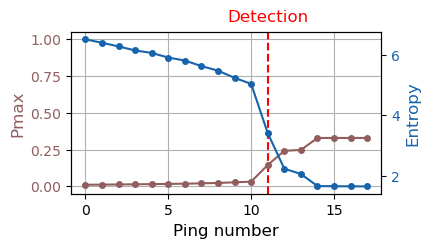

In [14]:
# Get data to plot
idx_detect = 11
h_actual_all = ds['h_actual_all'].values
p_max_all = ds['d_all'].max(dim="canvas").values

# Set up colors
cmap_tmp = matplotlib.colormaps["pink"]
colors_tmp = [cmap_tmp(c / 5) for c in range(5)]
colors = [colors_tmp[1]]
cmap_tmp = matplotlib.colormaps["Blues_r"]
colors_tmp = [cmap_tmp(c / 5) for c in range(5)]
colors.append(colors_tmp[1])


# First y-axis for pmax
fig, ax = plt.subplots(1, 1, figsize=(4, 2.1))
pingnum = len(h_actual_all[:p_converged])   # all ping number
ax.axvline(idx_detect, color="r", ls="--") # detect
ax.plot(np.arange(pingnum), p_max_all[:p_converged],  # pmax
        color=colors[0], marker='.', markersize=8, label='Pmax')
ax.plot([1, 1], [0, 1], ls="none")  # to get right legend and ylim

ax.set_xticks(np.arange(0, pingnum + 5, 5))
ax.set_xlabel('Ping number', fontsize=12)
ax.set_ylabel('Pmax', fontsize=12, color=colors[0])
ax.tick_params(axis='y', labelcolor=colors[0], labelsize=10)
ax.grid()

# Create second y-axis for pmax
ax2 = ax.twinx()
ax2.plot(np.arange(pingnum), h_actual_all[:p_converged],  # actual entropy
        color=colors[1], marker='.', markersize=8, label='Entropy')
ax2.set_ylabel('Entropy', fontsize=12, color=colors[1])
ax2.tick_params(axis='y', labelcolor=colors[1], labelsize=10)

ax2.text(x=idx_detect, y=7.1, s='Detection', color='red', fontsize=12, ha="center")


ax.set_xticks(np.arange(0, 20, 5))
ax.set_xticklabels(np.arange(0, 20, 5))


plt.show()

fig.savefig(path_fig / "fig_8B_MAP_search_B.png", dpi=300, bbox_inches="tight")